In [13]:
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt

import scipy
from scipy.optimize import minimize_scalar
from scipy.special import expit, logit
from scipy.stats import norm

import multiprocessing as mp

import sys

parent_dir = ".."
sys.path.append(parent_dir)

import utilities as utils

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "data/Murphy_pharma").is_dir()), None)
if ROOT is None:
    raise FileNotFoundError("Run from the repository or a subfolder containing data/Murphy_pharma above it.")
DATA_DIR = ROOT / "data/Murphy_pharma"
pd.set_option("display.max_columns", 24)
print(f"Data: {DATA_DIR}\nSciPy: {scipy.__version__}")

mean_neg, mean_pos = -28, 28
std = 28
P0 = np.array([[0.5], [0.5]])
Hlow = 0.1
Hhigh = 0.9

Data: /workspaces/Copy_Murphy2021/data/Murphy_pharma
SciPy: 1.11.4


In [14]:
from scipy.stats import norm

def P_source_g_samples(samples_arr,mean_neg,mean_pos,std,h,P0,window_size=None):
    P_sample_g_neg = np.diff(np.concatenate([np.array([0]),norm(loc=mean_neg,scale=std).cdf(np.arange(-89.5,90.5,1)),np.array([1])]))
    P_sample_g_pos = np.diff(np.concatenate([np.array([0]),norm(loc=mean_pos,scale=std).cdf(np.arange(-89.5,90.5,1)),np.array([1])]))
    # P_sample_g_neg = norm(loc=mean_neg, scale=std)
    # P_sample_g_pos = norm(loc=mean_pos, scale=std)
    Lneg = P_sample_g_neg[samples_arr + 90]
    Lpos = P_sample_g_pos[samples_arr + 90]
    L = np.concatenate((Lneg[:,np.newaxis,:],Lpos[:,np.newaxis,:]),axis=1)
    H = np.array([
        [1-h, h],
        [h, 1-h]
    ])
    P = P0.copy()
    if window_size is not None:
        L = L[:,:,-window_size:]
    for ii in range(L.shape[2]):
        P = L[:,:,ii][:,:,np.newaxis] * (H @ P)
    P = P / P.sum(axis=1, keepdims=True)
    return P.squeeze()

In [15]:
import multiprocessing as mp

import sys

parent_dir = ".."
sys.path.append(parent_dir)

import utilities as utils

def generate_trials(n_trials, n_draws, source_means, scale, H, mirror_trials=False, balanced_starts=False, seed=None):
    """Generate trials from a two-state switching Gaussian process.

    Parameters
    ----------
    n_trials : int
        Number of independent trials to generate.
    balanced_starts : bool, default=False
        If True, exactly half of the trials start in each source
        distribution. This requires an even ``n_trials``.
    seed : int or None, default=None
        Seed for NumPy's random-number generator. Use an integer for
        reproducible simulations.

    Returns
    -------
    X : ndarray of int, shape (n_trials, 12)
        Clipped and rounded observations for each trial.
    Y : ndarray of int, shape (n_trials,)
        Identity of the source for the final draw: 0 denotes the Gaussian
        with mean -17 and 1 denotes the Gaussian with mean 17.
    """
    if isinstance(n_trials, (bool, np.bool_)) or not isinstance(n_trials, (int, np.integer)):
        raise TypeError("n_trials must be an integer")
    if n_trials < 0:
        raise ValueError("n_trials must be non-negative")
    if (balanced_starts or mirror_trials) and n_trials % 2:
        raise ValueError("balanced_starts=True or mirror_trials=True requires an even n_trials")

    rng = np.random.default_rng(seed)
    n_draws = n_draws
    source_means = np.array(source_means)

    if mirror_trials:
        n_trials_ = n_trials // 2
    else:
        n_trials_ = n_trials

    if balanced_starts:
        starts = np.repeat([0, 1], n_trials_ // 2)
        rng.shuffle(starts)
    else:
        starts = rng.integers(0, 2, size=n_trials_)

    print(starts.shape)
    print(n_trials_)
    # switches[:, j] indicates whether the source changes between draws
    # j and j + 1. Cumulative parity therefore gives the source at each draw.
    switches = rng.random((n_trials_, n_draws - 1)) < H
    source_paths = np.column_stack(
        [starts, starts[:, None] ^ np.logical_xor.accumulate(switches, axis=1)]
    ).astype(int)

    raw_draws = rng.normal(loc=source_means[source_paths], scale=scale)
    X = np.rint(np.clip(raw_draws, -90, 90)).astype(int)
    Y = source_paths[:, -1].copy()
    if mirror_trials:
        X = np.concatenate([X, -X], axis=0)
        Y = np.concatenate([Y, 1-Y], axis=0)
    return X, Y

def IB_fn_emp(beta,p_RgX_emp,Yemp):
    Ixr = utils.compute_I_XR_emp(p_RgX_emp)
    Iry = utils.compute_I_RY_emp(p_RgX_emp,Yemp)
    return Ixr - beta*Iry

def mc_IB(beta,Ysample,p_YgX_sample,iterlimit=100000,init='random',N_inits=3,betastar=None,seed=209,return_dict=True):

    rng = np.random.default_rng(seed)

    N_y = p_YgX_sample.shape[1]
    N_x = p_YgX_sample.shape[0]

    Yoh = np.eye(N_y)[Ysample.astype(int)]

    IB_fxn_vals = []
    p_RgXs = []
    p_Rs = []
    p_YgRs = []

    for ii in range(N_inits):
        p_R = (np.ones(N_y) / N_y).reshape(1,-1)
        if init == 'random':
            p_RX = np.exp(rng.random((N_x,N_y)))
            p_RgX = p_RX / np.sum(p_RX,axis=1,keepdims=True)
        elif init == 'softmax':
            if betastar is None:
                betastar = beta
            p_RgX = np.exp(betastar*p_YgX_sample) / np.sum(np.exp(betastar*p_YgX_sample),axis=1,keepdims=True)
        p_RX = p_RgX * (1/N_x)
        p_XgR = p_RX / p_R
        p_YgR = Yoh.T @ p_XgR
        IB_fxn = IB_fn_emp(beta,p_RgX,Ysample)
        delta = 1
        iters = 0
        while (delta > 1e-15) or (iters < 100):
            # store last copy
            IB_fxn_last = IB_fxn

            # update p(r|x)
            p_RX = p_R * np.exp(beta*(p_YgX_sample @ np.log(p_YgR))) # we can simplify the original update rule (below) to this
            # p_RX = p_R * np.exp(-beta*np.sum(p_YgX[:,:,np.newaxis] * (np.log(p_YgX[:,:,np.newaxis]) - np.log(p_YgR[np.newaxis,:,:])),axis=1))
            p_RgX = p_RX / np.sum(p_RX,axis=1,keepdims=True)


            # update p(r)
            p_R = p_RgX.sum(axis=0,keepdims=True) / N_x

            #update p(y|r)
            p_RX = p_RgX * (1/N_x)
            p_XgR = p_RX / p_R
            p_YgR = Yoh.T @ p_XgR

            IB_fxn = IB_fn_emp(beta,p_RgX,Ysample)

            delta = np.abs(IB_fxn - IB_fxn_last)
            iters += 1
            if iters == iterlimit:
                break
        IB_fxn_vals.append(IB_fxn.copy())
        p_RgXs.append(p_RgX.copy())
        p_Rs.append(p_R.copy())
        p_YgRs.append(p_YgR.copy())

    min_ind = np.argmin(np.array(IB_fxn_vals))
    p_RgX = p_RgXs[min_ind]
    p_R = p_Rs[min_ind]
    p_YgR = p_YgRs[min_ind]

    H_R = -np.sum(p_R * np.log2(p_R))
    I_XR = utils.compute_I_XR_emp(p_RgX)
    I_RY = utils.compute_I_RY_emp(p_RgX,Ysample)

    if return_dict:
        out = {
            'I_XR': I_XR,
            'I_RY': I_RY,
            'beta': beta,
            'H_R': H_R,
            'p_YgR': p_YgR,
            'p_R': p_R,
            'betastar': betastar
        }
        return out
    else:
        return [I_XR, I_RY, beta, H_R, p_YgR, p_R, betastar]

def mc_IB_mp(args):
    return mc_IB(*args)

# mc_IB(beta,Ysample,p_YgX_sample,iterlimit=100000,init='random',N_inits=3,betastar=None,seed=209,return_dict=True)
def get_mc_IB_bound(Ysample,p_YgX_sample,N_b=100,max_b=50,iterlimit=100000,beta_array=None,init='random', N_inits=3, betastar_array=None, N_threads=1, seed=209, sort_by_beta=True):

    if beta_array is None:
        beta_array = np.linspace(max_b/N_b,max_b,N_b)

    with mp.Pool(processes=N_threads) as pool:
        results = [pool.apply_async(mc_IB_mp, args=((beta_array[ib], Ysample, p_YgX_sample, iterlimit, init, N_inits, betastar_array[ib] if betastar_array is not None else None, seed, False),)) for ib in range(N_b)]
        results = [res.get() for res in results]
    I_XR = [res[0] for res in results]
    I_RY = [res[1] for res in results]
    betas = [res[2] for res in results]
    H_Rs = [res[3] for res in results]
    p_YgRs = [res[4] for res in results]
    p_Rs = [res[5] for res in results]

    if sort_by_beta:
        sort_indices = np.argsort(betas)
    else:
        sort_indices = np.arange(len(betas))
    out = {
        'I_XR': np.array(I_XR)[sort_indices],
        'I_RY': np.array(I_RY)[sort_indices],
        'beta': np.array(betas)[sort_indices],
        'H_R': np.array(H_Rs)[sort_indices],
        'p_YgR': np.array(p_YgRs)[sort_indices],
        'p_R': np.array(p_Rs)[sort_indices]
    }
    return out

In [75]:
n_draws = 10
source_means = [-28.0, 28.0]
mean_neg, mean_pos = source_means
std = 28.0
Hlow = 0.1
Hhigh = 0.9
Ntrials = 100000
Xlow, Ylow = generate_trials(Ntrials, n_draws, source_means, std, Hlow, mirror_trials=True, balanced_starts=True, seed=None)
Xhigh, Yhigh = generate_trials(Ntrials, n_draws, source_means, std, Hhigh, mirror_trials=True, balanced_starts=True, seed=None)

(50000,)
50000
(50000,)
50000


In [76]:
P_sample_g_neg = np.diff(np.concatenate([np.array([0]),norm(loc=mean_neg,scale=std).cdf(np.arange(-89.5,90.5,1)),np.array([1])]))
P_sample_g_pos = np.diff(np.concatenate([np.array([0]),norm(loc=mean_pos,scale=std).cdf(np.arange(-89.5,90.5,1)),np.array([1])]))
P_sample = (P_sample_g_neg + P_sample_g_pos) / 2

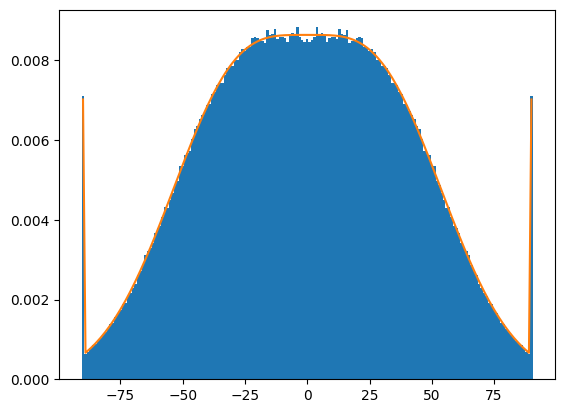

In [77]:
plt.hist(Xlow.flatten(), bins=np.arange(-90.5, 91.5, 1), density=True)
plt.plot(np.arange(-90, 91, 1), P_sample)

In [78]:
P0 = np.array([[0.5], [0.5]])
p_YgX_sample = P_source_g_samples(Xlow,mean_neg,mean_pos,std,Hlow,P0,window_size=None)
N_threads = 15
IB_bound_low = get_mc_IB_bound(Ylow,p_YgX_sample,N_b=100,max_b=50,iterlimit=100000,beta_array=None,init='random', N_inits=3, betastar_array=None, N_threads=N_threads, seed=209, sort_by_beta=True)

KeyboardInterrupt: 

In [ ]:
plt.plot(IB_bound_low['I_XR'],IB_bound_low['I_RY'])

In [21]:
metadata_df = pd.read_csv('metadata.csv')
trials_df = pd.read_csv('trials.csv')
stimuli_df = pd.read_csv('stimuli.csv')

In [22]:
metadata_df

,participant,session,run,H,drug,n_blocks,n_trials,block_numbers,block_number_gap
0,CMC,1,1,0.9,atomoxetine,8,688,"(1, 2, 3, 4, 5, 6, 7, 8)",False
1,CMC,1,2,0.1,atomoxetine,8,688,"(1, 2, 3, 4, 5, 6, 7, 8)",False
2,CMC,2,1,0.1,placebo,8,688,"(1, 2, 3, 4, 5, 6, 7, 8)",False
3,CMC,2,2,0.9,placebo,8,688,"(1, 2, 3, 4, 5, 6, 7, 8)",False
4,CMC,3,1,0.9,donepizil,8,647,"(1, 2, 3, 4, 5, 6, 7, 8)",False
...,...,...,...,...,...,...,...,...,...
175,XUE,1,2,0.9,atomoxetine,8,688,"(1, 2, 3, 4, 5, 6, 7, 8)",False
176,XUE,2,1,0.1,donepizil,8,688,"(1, 2, 3, 4, 5, 6, 7, 8)",False
177,XUE,2,2,0.9,donepizil,8,688,"(1, 2, 3, 4, 5, 6, 7, 8)",False
178,XUE,3,1,0.9,placebo,8,688,"(1, 2, 3, 4, 5, 6, 7, 8)",False


In [23]:
trials_df

,final_distribution,response,accuracy,rt_s,start_time_raw,fixation_break_count,trial_id,participant,session,run,block,trial_in_block,n_samples,n_samples_presented,source_behavior,presentation_complete,valid_response,analysis_valid,has_fixation_break,planned_final_distribution,H,drug
0,2.0,2.0,1.0,0.046685,1.517912e+09,0.0,CMC_S1_R1_B1_T1,CMC,1,1,1,1,10,10,CMC/CMC/S1/R1/Behaviour/CMC_1_1.mat,True,True,True,False,2.0,0.9,atomoxetine
1,1.0,1.0,1.0,0.812104,1.517912e+09,0.0,CMC_S1_R1_B1_T2,CMC,1,1,1,2,5,5,CMC/CMC/S1/R1/Behaviour/CMC_1_1.mat,True,True,True,False,1.0,0.9,atomoxetine
2,1.0,1.0,1.0,0.954936,1.517912e+09,0.0,CMC_S1_R1_B1_T3,CMC,1,1,1,3,10,10,CMC/CMC/S1/R1/Behaviour/CMC_1_1.mat,True,True,True,False,1.0,0.9,atomoxetine
3,1.0,2.0,0.0,0.470086,1.517912e+09,0.0,CMC_S1_R1_B1_T4,CMC,1,1,1,4,10,10,CMC/CMC/S1/R1/Behaviour/CMC_1_1.mat,True,True,True,False,1.0,0.9,atomoxetine
4,1.0,1.0,1.0,0.623945,1.517912e+09,0.0,CMC_S1_R1_B1_T5,CMC,1,1,1,5,10,10,CMC/CMC/S1/R1/Behaviour/CMC_1_1.mat,True,True,True,False,1.0,0.9,atomoxetine
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120887,2.0,2.0,1.0,0.311655,1.512147e+09,0.0,XUE_S3_R2_B8_T82,XUE,3,2,8,82,10,10,XUE/XUE/S3/R2/Behaviour/XUE_3_8.mat,True,True,True,False,2.0,0.1,placebo
120888,1.0,1.0,1.0,0.031287,1.512147e+09,0.0,XUE_S3_R2_B8_T83,XUE,3,2,8,83,10,10,XUE/XUE/S3/R2/Behaviour/XUE_3_8.mat,True,True,True,False,1.0,0.1,placebo
120889,1.0,1.0,1.0,0.096594,1.512147e+09,0.0,XUE_S3_R2_B8_T84,XUE,3,2,8,84,9,9,XUE/XUE/S3/R2/Behaviour/XUE_3_8.mat,True,True,True,False,1.0,0.1,placebo
120890,2.0,2.0,1.0,0.062127,1.512147e+09,0.0,XUE_S3_R2_B8_T85,XUE,3,2,8,85,4,4,XUE/XUE/S3/R2/Behaviour/XUE_3_8.mat,True,True,True,False,2.0,0.1,placebo


In [24]:
stimuli_df

,trial_id,sample_in_trial,stimulus_value,generating_distribution,switch,onset_s,presented,participant,session,run,block,trial_in_block,drug,H,analysis_valid
0,CMC_S1_R1_B1_T1,1,1.0,1.0,0.0,0.400007,True,CMC,1,1,1,1,atomoxetine,0.9,True
1,CMC_S1_R1_B1_T1,2,-45.0,2.0,1.0,0.799996,True,CMC,1,1,1,1,atomoxetine,0.9,True
2,CMC_S1_R1_B1_T1,3,50.0,1.0,1.0,1.199986,True,CMC,1,1,1,1,atomoxetine,0.9,True
3,CMC_S1_R1_B1_T1,4,-84.0,2.0,1.0,1.599990,True,CMC,1,1,1,1,atomoxetine,0.9,True
4,CMC_S1_R1_B1_T1,5,21.0,1.0,1.0,1.999984,True,CMC,1,1,1,1,atomoxetine,0.9,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1019142,XUE_S3_R2_B8_T86,6,20.0,1.0,0.0,2.399967,True,XUE,3,2,8,86,placebo,0.1,True
1019143,XUE_S3_R2_B8_T86,7,12.0,1.0,0.0,2.799972,True,XUE,3,2,8,86,placebo,0.1,True
1019144,XUE_S3_R2_B8_T86,8,5.0,1.0,0.0,3.199954,True,XUE,3,2,8,86,placebo,0.1,True
1019145,XUE_S3_R2_B8_T86,9,69.0,1.0,0.0,3.599953,True,XUE,3,2,8,86,placebo,0.1,True


In [73]:
from choice_information import (
    default_model_library,
    estimate_choice_information,
    bootstrap_choice_information,
    plot_choice_information_diagnostics,
    plot_bootstrap_choice_information,
)

ibdf = pd.DataFrame({
    'subject_ID': [],
    'subject_index': [],
    'session': [],
    'run': [],
    'H': [],
    'drug': [],
    'Ntrials': [],
    'Ixr': [],
    'Iry': [],
    'Iry_CI_lower': [],
    'Iry_CI_upper': []
})

Rcard = 2
Ycard = 2

CI = (2.5, 97.5)
boot_iters = 1000 # number of bootstrap iterations
N_threads = 15 # number of threads for parallel processing

participants = metadata_df['participant'].unique()
drugs = metadata_df['drug'].unique()
H_values = metadata_df['H'].unique()

# participants = ['CMC']

for ii, participant in enumerate(participants):
    sjtrials_df = trials_df.loc[trials_df['participant'] == participant]
    sjstimuli_df = stimuli_df.loc[stimuli_df['participant'] == participant]
    conds = (sjtrials_df['n_samples_presented']==10) & (sjtrials_df['valid_response']) & (sjtrials_df['presentation_complete'])
    for drug in drugs:
        conds2 = conds & (sjtrials_df['drug'] == drug)
        for H in H_values:
            conds3 = conds2 & (sjtrials_df['H'] == H)
            trials = sjtrials_df.loc[conds3,'trial_id']
            X = np.array([sjstimuli_df.loc[sjstimuli_df['trial_id']==trial_id,'stimulus_value'].values for trial_id in trials])
            R = np.array([sjtrials_df.loc[sjtrials_df['trial_id']==trial_id,'response'].values for trial_id in trials], dtype=int).squeeze()
            Y = np.array([sjtrials_df.loc[sjtrials_df['trial_id']==trial_id,'final_distribution'].values for trial_id in trials], dtype=int).squeeze()

            R = R - 1
            Y = Y - 1

            result = estimate_choice_information(
                    X,
                    R,
                    fold_mode="random",
                    n_splits=5,
                    inner_n_splits=3,
                    random_state=2026,
                )

            Ixr = result["mi_lower_bound_bits"]
            Iry = utils.mutual_inf_nsb(R, Y, [Rcard, Ycard])

            Iry_CI = utils.get_Iry_CI(R,Y,CI,boot_iters,Rcard=Rcard,Ycard=Ycard,seed=234,N_threads=N_threads)

            sjdf = pd.DataFrame({
                'subject_ID': [''],
                'subject_index': [np.nan],
                'session': [np.nan],
                'run': [np.nan],
                'drug': [''],
                'H': [np.nan],
                'Ixr': [np.nan],
                'Iry': [np.nan],
                'Iry_CI_lower': [np.nan],
                'Iry_CI_upper': [np.nan]
            })

            conds4 = (metadata_df['participant'] == participant) & (metadata_df['drug'] == drug) & (metadata_df['H'] == H)

            sjdf['subject_ID'] = participant
            sjdf['subject_index'] = ii
            sjdf['session'] = metadata_df.loc[conds4, 'session'].values[0]
            sjdf['run'] = metadata_df.loc[conds4, 'run'].values[0]
            sjdf['drug'] = drug
            sjdf['H'] = H
            sjdf['Ixr'] = Ixr
            sjdf['Iry'] = Iry
            sjdf['Iry_CI_lower'] = Iry_CI[0]
            sjdf['Iry_CI_upper'] = Iry_CI[1]

            ibdf = pd.concat([ibdf, sjdf], ignore_index=True)

In [79]:
ibdf.to_csv('ibdf.csv')

In [74]:
ibdf

,subject_ID,subject_index,session,run,H,drug,Ntrials,Ixr,Iry,Iry_CI_lower,Iry_CI_upper
0,CMC,0.0,1.0,1.0,0.9,atomoxetine,NaN,0.494586,0.325351,0.252697,0.407877
1,CMC,0.0,1.0,2.0,0.1,atomoxetine,NaN,0.449716,0.291766,0.220310,0.365524
2,CMC,0.0,2.0,2.0,0.9,placebo,NaN,0.587011,0.312079,0.241317,0.396254
3,CMC,0.0,2.0,1.0,0.1,placebo,NaN,0.529696,0.312238,0.241537,0.408838
4,CMC,0.0,3.0,1.0,0.9,donepizil,NaN,0.345680,0.281320,0.208357,0.363210
...,...,...,...,...,...,...,...,...,...,...,...
175,XUE,29.0,1.0,1.0,0.1,atomoxetine,NaN,0.769634,0.475547,0.393862,0.566326
176,XUE,29.0,3.0,1.0,0.9,placebo,NaN,0.928532,0.365547,0.291228,0.455457
177,XUE,29.0,3.0,2.0,0.1,placebo,NaN,0.786294,0.425226,0.340754,0.510967
178,XUE,29.0,2.0,2.0,0.9,donepizil,NaN,0.855971,0.281407,0.214199,0.358625
